# Otimização avançada da Árvore de Decisão - busca maior, escala log e curva ROC/AUC

Notebook dedicado só à Árvore de Decisão, separado do `10_otimizacao_modelo.ipynb`.
Motivo de existir separado: entre os quatro candidatos da etapa de otimização,
a Árvore é de longe o mais barato de treinar (75s pra 64 combinações no
notebook 10), então compensa gastar mais tempo de busca só nela, com uma
grade bem maior do que caberia fazer nos outros três sem estourar o tempo
total daquele notebook.

Objetivos deste notebook:
1. Listar os hiperparâmetros do `DecisionTreeClassifier` e explicar quais
   costumam ser ajustados na prática.
2. Rodar uma busca bem mais ampla que a do notebook 10 (mais valores de
   `min_samples_leaf`/`min_samples_split`, e `ccp_alpha` varrido em escala
   log, além do `criterion`).
3. Olhar explicitamente o gap treino-validação cruzada de cada combinação
   testada, não só a acurácia média - com atenção especial a configurações
   com `max_depth=None`, que podem estar decorando o treino em vez de
   generalizar.
4. Fazer a curva ROC e calcular a AUC, comparando a árvore do baseline, a
   árvore otimizada no notebook 10 e a árvore desta busca mais pesada.

**Ainda não é uma decisão fechada.** O resultado daqui entra como mais um
dado pra decidir o modelo final, junto com o que já saiu do notebook 10.


## 1. Dataset e split (idêntico às etapas anteriores)

Mesma função, mesmo `random_state=42` - o recorte de treino/validação aqui é
exatamente o mesmo dos notebooks 09 e 10. Não existe uma terceira partição
física de "teste" (ver Achado 42 em `reports/decisoes.md`): a validação
cruzada dentro do treino cumpre esse papel durante toda a busca de
hiperparâmetro, e a validação de 20% só é usada no fim, uma única vez.


In [1]:
import sys
sys.path.append("../..")

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import randint, loguniform

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score

from src.preprocessing.pipeline import carregar_dataset_modelagem, construir_preprocessador
from src.visualization.graficos import plot_arvore, plot_importancia_features

pd.set_option("display.max_columns", 100)


In [2]:
X, y = carregar_dataset_modelagem()

X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)
print(f"Treino: {X_treino.shape}")
print(f"Validação final - cofre fechado, não toco até o fim: {X_validacao.shape}")


Lendo base_escola_modelo do cache local: C:\Users\wesle\dev\ai-scientist-tech-challenge-3-modeling\data\processed\base_escola_modelo.parquet
Escolas com ideb preenchido: 42273 de 63537 (66.5%) - só essas entram no dataset de modelagem.
acesso_internet_computador: 1009 escolas com código 9 (não informado) -> viraram nulo.
tratamento_lixo_inexistente: 57 escolas com código 9 (não informado) -> viraram nulo.
tratamento_lixo_reciclagem: 57 escolas com código 9 (não informado) -> viraram nulo.
redes_sociais: 546 escolas com código 9 (não informado) -> viraram nulo.
Treino: (33818, 47)
Validação final - cofre fechado, não toco até o fim: (8455, 47)


## 2. Hiperparâmetros do `DecisionTreeClassifier` - o que existe e o que costuma ser ajustado

Antes de ampliar a busca, vale listar os hiperparâmetros reais da classe
(`sklearn.tree.DecisionTreeClassifier`), pra deixar claro o que estou testando
e por quê:

| Hiperparâmetro | O que controla | Ajusto aqui? |
|---|---|---|
| `criterion` | Métrica de qualidade de cada divisão (`gini`, `entropy`, ou `log_loss`, equivalente a `entropy` na prática binária) | Sim - `gini` x `entropy` |
| `max_depth` | Profundidade máxima da árvore - controle mais direto de complexidade/overfitting | Sim - de valores rasos até `None` (sem limite) |
| `min_samples_split` | Nº mínimo de amostras num nó pra ele poder ser dividido | Sim |
| `min_samples_leaf` | Nº mínimo de amostras que uma folha final precisa ter | Sim |
| `ccp_alpha` | Parâmetro de poda por complexidade de custo (Cost-Complexity Pruning) - poda a árvore *depois* de crescida, cortando ramos que não compensam o ganho de pureza pelo custo de complexidade adicionada | Sim - em escala log |
| `splitter` | Como escolhe o ponto de corte em cada nó: `best` (o melhor entre todas as features) ou `random` (aleatório entre um subconjunto) | Não - `best` quase sempre vence numa árvore única (o `random` existe mais pra compor ensembles como o Extra-Trees) |
| `max_features` | Quantas features considerar em cada divisão | Não - faz mais sentido em ensembles (Random Forest); numa árvore única eu quero que ela veja todas as features disponíveis em cada corte |
| `max_leaf_nodes` | Limita o número total de folhas (cresce a árvore priorizando os cortes de maior ganho primeiro) | Não - redundante com `max_depth`/`min_samples_leaf` já cobrindo o mesmo tipo de controle |
| `min_weight_fraction_leaf` | Como `min_samples_leaf`, mas em fração do total de peso das amostras (útil com `sample_weight`) | Não - não uso pesos de amostra neste projeto |
| `min_impurity_decrease` | Só divide um nó se a divisão reduzir a impureza em pelo menos esse valor | Não - `ccp_alpha` já cobre uma forma de regularização parecida, mais estudada na literatura |
| `class_weight` | Pondera as classes de forma diferente (útil com desbalanceamento forte) | Não - o alvo já é levemente desbalanceado e não tratei os outros modelos assim, pra manter a comparação justa |
| `random_state` | Fixa a semente (só importa de fato quando `splitter="random"` ou `max_features` < total) | Fixo em 42, por padrão do projeto |

**Na prática, os mais usados no dia a dia (e os que testo aqui) são
`max_depth`, `min_samples_leaf`, `min_samples_split`, `criterion` e
`ccp_alpha`** - são os que controlam diretamente o trade-off entre a árvore
aprender o suficiente e a árvore decorar o treino.


## 3. Por que uma busca maior, em escala log, e de olho no overfitting

**Grade maior:** a busca do notebook 10 testou só 64 combinações
(`max_depth` x `min_samples_leaf` x `criterion`). Como um fit de árvore é
muito mais barato que os outros três candidatos (75s pra rodar a grade
inteira, contra 82,8s de só uma grade de Random Forest bem mais enxuta),
dá pra testar uma grade bem mais ampla sem custo proibitivo.

**Escala log pro `ccp_alpha`:** esse hiperparâmetro tem efeito multiplicativo,
não aditivo (a diferença entre 0,0001 e 0,001 importa tanto quanto a
diferença entre 0,001 e 0,01) - amostrar em escala linear desperdiçaria a
maior parte das tentativas numa faixa de valores pouco informativa, o mesmo
raciocínio já usado pro `C`/`gamma` do SVM no notebook 10. Por isso, em vez
de um `GridSearchCV` com uma grade fixa de `ccp_alpha`, uso `RandomizedSearchCV`
com `loguniform`, que amostra minha escolha de forma proporcionalmente
espalhada por várias ordens de grandeza.

**Cuidado com overfitting:** um `max_depth=None` associado a um
`min_samples_leaf` pequeno é receita clássica pra árvore decorar o treino -
cada folha pode ficar tão específica que memoriza casos individuais em vez
de aprender um padrão que generaliza. O notebook 10 encontrou `max_depth=None`
como vencedor, mas só porque `min_samples_leaf=50` (o maior valor testado
na grade) já limitava bastante o tamanho mínimo de cada folha - na prática,
"`max_depth=None`" ali não significa "sem controle nenhum", significa "a
árvore para de crescer quando as folhas ficam pequenas demais, não quando
bate um teto de profundidade". Ainda assim, é um ponto de atenção real: uma
combinação com acurácia de validação cruzada só um pouco maior mas um gap
treino-validação bem maior é sinal de que a árvore está generalizando pior
do que a média de CV sozinha sugere. Por isso, ativo `return_train_score=True`
na busca, pra ter esse gap disponível pra cada combinação testada, não só a
acurácia média.

**Tempo estimado:** com `n_iter=400` (contra as 64 combinações do notebook
10) e o mesmo `cv_padrao` de 5 folds, a expectativa é algo entre 5 e 15
minutos, dependendo de quantas combinações sorteadas caem em árvores mais
profundas/com folhas pequenas (mais caras de treinar) - bem mais barato que
o SVM otimizado do notebook 10 (17,5 minutos, numa grade de só 18
combinações).


In [3]:
cv_padrao = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_arvore = Pipeline([
    ("prep", construir_preprocessador(escalar_numericas=False)),
    ("clf", DecisionTreeClassifier(random_state=42)),
])

distribuicao_arvore = {
    "clf__criterion": ["gini", "entropy"],
    "clf__max_depth": [3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, None],
    "clf__min_samples_leaf": randint(1, 151),
    "clf__min_samples_split": randint(2, 151),
    "clf__ccp_alpha": loguniform(1e-6, 5e-2),
}

t0 = time.time()
busca_arvore_pesada = RandomizedSearchCV(
    pipe_arvore, distribuicao_arvore, n_iter=400, cv=cv_padrao,
    scoring="accuracy", n_jobs=-1, random_state=42, return_train_score=True,
)
busca_arvore_pesada.fit(X_treino, y_treino)
print(f"Tempo: {time.time() - t0:.1f}s")
print(f"Melhor combinação (só por acurácia de teste/CV): {busca_arvore_pesada.best_params_}")
print(f"Acurácia média (CV, treino): {busca_arvore_pesada.best_score_:.4f}")


c:\Users\wesle\dev\ai-scientist-tech-challenge-3-modeling\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Tempo: 1360.1s
Melhor combinação (só por acurácia de teste/CV): {'clf__ccp_alpha': np.float64(7.300332477682831e-05), 'clf__criterion': 'gini', 'clf__max_depth': 15, 'clf__min_samples_leaf': 51, 'clf__min_samples_split': 82}
Acurácia média (CV, treino): 0.7322


## 4. Diagnóstico de overfitting: treino x validação cruzada, combinação a combinação

`return_train_score=True` guarda, pra cada combinação testada, tanto a
acurácia média nos folds de teste da validação cruzada (`mean_test_score`,
o que o `GridSearchCV`/`RandomizedSearchCV` normalmente reporta sozinho)
quanto a acurácia média nos folds de treino de cada fold (`mean_train_score`)
- ou seja, dá pra calcular o gap das duas sem rodar nada extra.

Olho as 20 combinações com melhor `mean_test_score` e calculo o gap de cada
uma - uma combinação com gap grande é sinal de que está decorando o treino
mais do que as outras, mesmo que a acurácia de CV pareça boa.


In [4]:
resultados_busca = pd.DataFrame(busca_arvore_pesada.cv_results_)
resultados_busca["gap_treino_cv"] = (
    resultados_busca["mean_train_score"] - resultados_busca["mean_test_score"]
)

colunas_interesse = [
    "param_clf__criterion", "param_clf__max_depth", "param_clf__min_samples_leaf",
    "param_clf__min_samples_split", "param_clf__ccp_alpha",
    "mean_train_score", "mean_test_score", "gap_treino_cv",
]

top20 = resultados_busca.sort_values("mean_test_score", ascending=False).head(20)[colunas_interesse]
top20 = top20.reset_index(drop=True)
top20


,param_clf__criterion,param_clf__max_depth,param_clf__min_samples_leaf,param_clf__min_samples_split,param_clf__ccp_alpha,mean_train_score,mean_test_score,gap_treino_cv
0,gini,15,51,82,0.000073,0.744086,0.732214,0.011872
1,gini,15,24,149,0.000007,0.745040,0.730499,0.014541
2,gini,15,15,52,0.000292,0.736546,0.730440,0.006106
3,gini,15,34,14,0.000092,0.746562,0.730381,0.016182
4,gini,15,42,125,0.000209,0.738202,0.730381,0.007821
5,gini,None,78,118,0.000003,0.741691,0.730321,0.011370
6,gini,15,14,57,0.000149,0.745284,0.730026,0.015258
7,gini,None,28,82,0.000318,0.736191,0.729878,0.006313
8,gini,12,56,95,0.000003,0.736427,0.729848,0.006579
9,gini,15,76,95,0.000036,0.740271,0.729848,0.010423


## 5. Escolha final: acurácia boa, mas sem abrir mão de generalização

Entre as 20 combinações com melhor acurácia de validação cruzada, escolho a
de menor gap treino-CV, desde que a acurácia dela não fique mais de 0,3 ponto
percentual abaixo da melhor do grupo - ou seja, não pego a combinação mais
"decorada" só porque ela tem a maior média de CV por uma margem mínima, se
existe uma alternativa quase tão boa e mais estável. Essa regra é meu
critério, não uma convenção do scikit-learn - fica registrado aqui de forma
explícita, e a tabela acima deixa visível a comparação completa caso eu
queira escolher diferente.


In [5]:
melhor_acuracia_top20 = top20["mean_test_score"].max()
candidatos_bons = top20[top20["mean_test_score"] >= melhor_acuracia_top20 - 0.003]
vencedor = candidatos_bons.sort_values("gap_treino_cv").iloc[0]

print("Combinação escolhida (melhor acurácia dentro do grupo de menor gap):")
print(vencedor)

parametros_vencedores = dict(
    criterion=vencedor["param_clf__criterion"],
    max_depth=vencedor["param_clf__max_depth"],
    min_samples_leaf=int(vencedor["param_clf__min_samples_leaf"]),
    min_samples_split=int(vencedor["param_clf__min_samples_split"]),
    ccp_alpha=float(vencedor["param_clf__ccp_alpha"]),
    random_state=42,
)
print("\nParâmetros pra reconstruir o modelo:", parametros_vencedores)


Combinação escolhida (melhor acurácia dentro do grupo de menor gap):
param_clf__criterion                gini
param_clf__max_depth                  15
param_clf__min_samples_leaf           15
param_clf__min_samples_split          52
param_clf__ccp_alpha            0.000292
mean_train_score                0.736546
mean_test_score                  0.73044
gap_treino_cv                   0.006106
Name: 2, dtype: object

Parâmetros pra reconstruir o modelo: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 15, 'min_samples_split': 52, 'ccp_alpha': 0.0002923481753472626, 'random_state': 42}


## 6. Comparação final: baseline, árvore leve (notebook 10) e árvore desta busca pesada

Refito as três versões da árvore no treino inteiro (nunca na validação) e
comparo a acurácia de CV (treino) e a acurácia na validação, pra ver se a
busca mais pesada realmente trouxe algum ganho real, e se não trouxe
overfitting escondido que só aparece fora do treino.


In [6]:
pipe_arvore_baseline = Pipeline([
    ("prep", construir_preprocessador(escalar_numericas=False)),
    ("clf", DecisionTreeClassifier(max_depth=4, random_state=42)),
])

pipe_arvore_leve = Pipeline([
    ("prep", construir_preprocessador(escalar_numericas=False)),
    ("clf", DecisionTreeClassifier(
        criterion="gini", max_depth=None, min_samples_leaf=50, random_state=42,
    )),
])

pipe_arvore_pesada = Pipeline([
    ("prep", construir_preprocessador(escalar_numericas=False)),
    ("clf", DecisionTreeClassifier(**parametros_vencedores)),
])

arvores = {
    "Baseline (max_depth=4)": pipe_arvore_baseline,
    "Notebook 10 (busca leve)": pipe_arvore_leve,
    "Este notebook (busca pesada)": pipe_arvore_pesada,
}

linhas_comparacao = []
for nome, pipe in arvores.items():
    t0 = time.time()
    acuracia_cv = cross_val_predict(pipe, X_treino, y_treino, cv=cv_padrao, method="predict")
    acuracia_cv = accuracy_score(y_treino, acuracia_cv)

    pipe.fit(X_treino, y_treino)
    acuracia_validacao = accuracy_score(y_validacao, pipe.predict(X_validacao))

    linhas_comparacao.append({
        "Árvore": nome,
        "Acurácia treino (CV)": acuracia_cv,
        "Acurácia validação": acuracia_validacao,
        "Gap (CV - validação)": acuracia_cv - acuracia_validacao,
        "Tempo (s)": time.time() - t0,
    })

tabela_comparacao_arvores = pd.DataFrame(linhas_comparacao)
tabela_comparacao_arvores


,Árvore,Acurácia treino (CV),Acurácia validação,Gap (CV - validação),Tempo (s)
0,Baseline (max_depth=4),0.683453,0.674630,0.008822,6.538369
1,Notebook 10 (busca leve),0.729375,0.731520,-0.002145,8.220169
2,Este notebook (busca pesada),0.730439,0.722413,0.008027,5.611070


## 7. Curva ROC e AUC

A curva ROC mostra a taxa de verdadeiro positivo contra a taxa de falso
positivo pra todos os limiares de decisão possíveis, não só o padrão de 0,5.
A AUC (área sob essa curva) resume isso num número entre 0,5 (aleatório) e
1,0 (separação perfeita) - e não depende de onde eu fixo o limiar, o que é
útil aqui porque o corte `ideb >= 6.0` já é uma escolha um pouco arbitrária
em si.

Uso `predict_proba` (a Árvore de Decisão tem nativamente) pra pegar a
probabilidade da classe "Sim" e comparo as três versões na validação - a
mesma base, avaliada uma única vez, igual venho fazendo com o resto das
métricas finais.


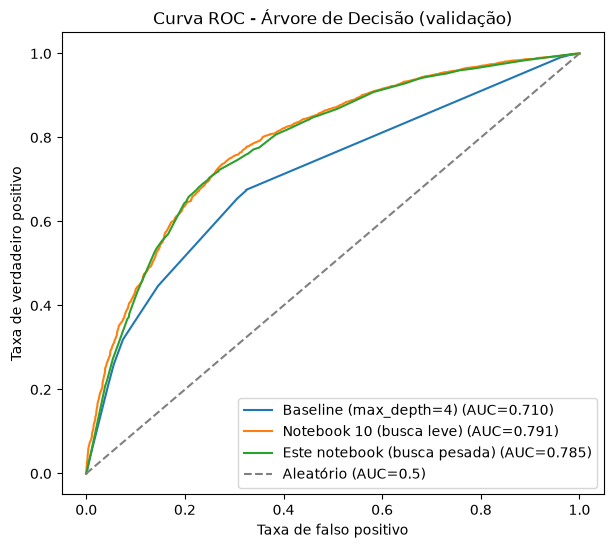

In [7]:
plt.figure(figsize=(7, 6))

for nome, pipe in arvores.items():
    scores_validacao = pipe.predict_proba(X_validacao)[:, 1]
    auc = roc_auc_score(y_validacao, scores_validacao)
    fpr, tpr, _ = roc_curve(y_validacao, scores_validacao)
    plt.plot(fpr, tpr, label=f"{nome} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "--", color="gray", label="Aleatório (AUC=0.5)")
plt.xlabel("Taxa de falso positivo")
plt.ylabel("Taxa de verdadeiro positivo")
plt.title("Curva ROC - Árvore de Decisão (validação)")
plt.legend()
plt.show()


**Como isso ajuda a interpretar o modelo, além da acurácia:** a curva
deixa visível o trade-off entre "pegar mais escolas em risco" (recall alto,
mais falso positivo) e "não soar alarme falso" (precisão alta). Num contexto
de política pública, dá pra escolher um limiar diferente de 0,5 dependendo
da prioridade do gestor - por exemplo, baixar o limiar de decisão pra não
deixar passar uma escola que de fato não vai bater a meta, mesmo aceitando
mais casos de falso alarme. Isso é uma decisão de política, não uma decisão
técnica do modelo em si, mas a curva ROC é a ferramenta que deixa essa
escolha explícita e visível, em vez de escondida atrás de um limiar de 0,5
fixo por padrão.


## 8. Desenho da árvore escolhida e importância de feature


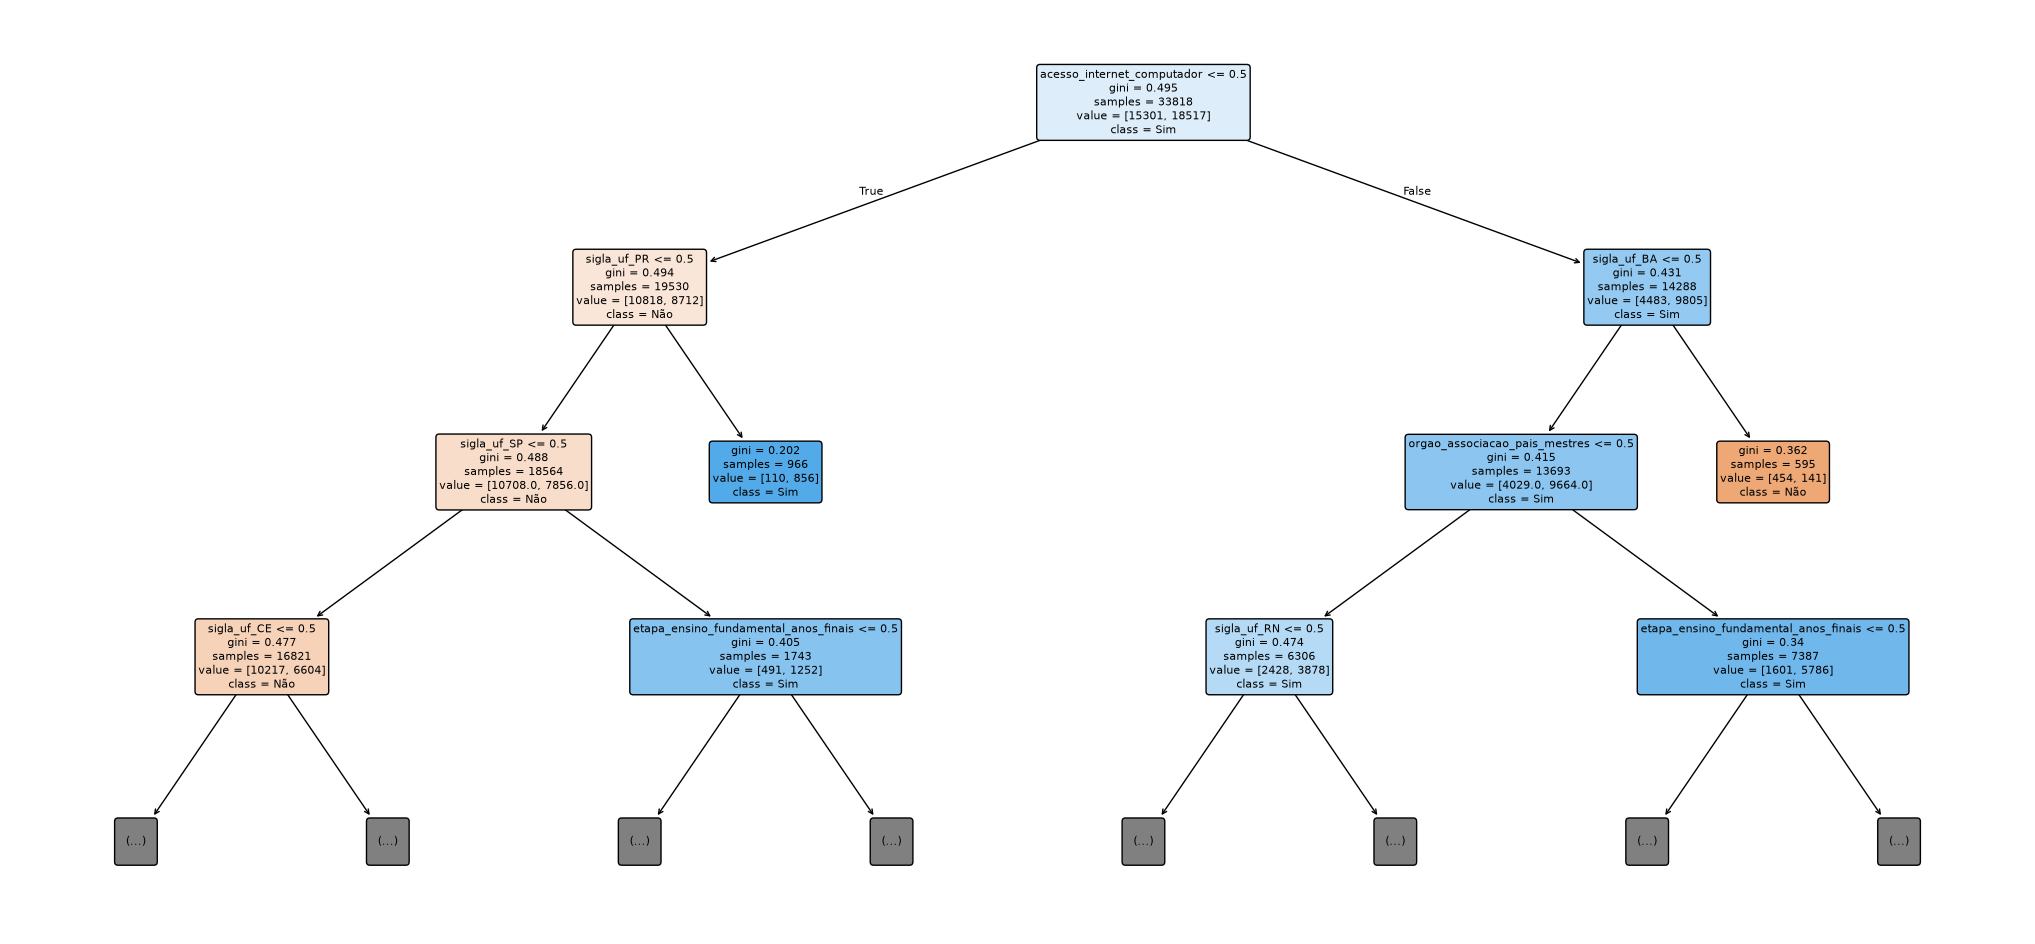

In [8]:
arvore_pesada_treinada = pipe_arvore_pesada.named_steps["clf"]
nomes_arvore_pesada = pipe_arvore_pesada.named_steps["prep"].get_feature_names_out()

plot_arvore(
    arvore_pesada_treinada, nomes_arvore_pesada,
    figsize=(26, 12), profundidade_exibicao=3,
)


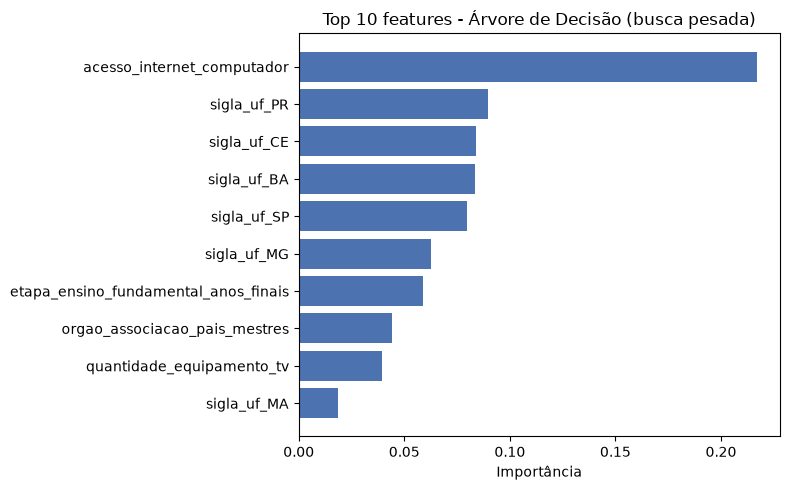

In [9]:
importancias_arvore_pesada = pd.Series(
    arvore_pesada_treinada.feature_importances_,
    index=[n.split("__", 1)[1] if "__" in n else n for n in nomes_arvore_pesada],
)
plot_importancia_features(
    importancias_arvore_pesada, top_n=10,
    titulo="Top 10 features - Árvore de Decisão (busca pesada)",
)


## 9. Síntese

Este notebook respondia duas perguntas: (1) uma busca bem maior, com escala
log e atenção ao overfitting, melhora a Árvore de Decisão de forma real, sem
só decorar o treino? e (2) como ela se compara ao candidato do notebook 10
via AUC, não só acurácia?

**Resultado (Seção 6 e 7):**

| Árvore | Acurácia treino (CV) | Acurácia validação | Gap (CV - validação) | AUC (validação) |
|---|---|---|---|---|
| Baseline (`max_depth=4`) | 0,6835 | 0,6746 | 0,0088 | 0,710 |
| Notebook 10 (busca leve, 64 combinações) | 0,7294 | 0,7315 | -0,0021 | 0,791 |
| Este notebook (busca pesada, 400 combinações) | 0,7304 | 0,7224 | 0,0080 | 0,785 |

A busca pesada (`RandomizedSearchCV` com 400 combinações, escala log no
`ccp_alpha`, critério de seleção que penaliza gap treino-CV) achou uma
combinação com acurácia de CV levemente maior que a busca leve do notebook
10 (0,7304 contra 0,7294), mas essa vantagem não se sustenta na validação:
a árvore da busca leve generaliza melhor (0,7315 de acurácia e 0,791 de AUC
na validação, contra 0,7224 e 0,785 da busca pesada), inclusive com gap
treino-validação favorável (negativo), o que a busca pesada não conseguiu
replicar apesar do critério de seleção ter sido desenhado justamente pra
evitar isso.

Ou seja: resposta à pergunta (1) é sim, uma busca maior encontra uma
combinação com acurácia de CV um pouco melhor, mas não necessariamente uma
árvore que generaliza melhor - o ganho de CV não se traduziu em ganho na
validação, que é o que importa de verdade. Resposta à pergunta (2): mesmo a
melhor árvore encontrada aqui não supera a árvore mais simples do notebook
10 fora da amostra de treino.

**Decisão:** fico com a configuração mais simples do notebook 10
(`min_samples_leaf=50`, sem limitar `max_depth`, critério gini) como a
Árvore de Decisão final do projeto. Não vale a pena trocar por uma
configuração mais complexa (`max_depth=15`, `min_samples_split=52`,
`ccp_alpha≈0,00029`) que custou 400 combinações de busca (1360s) pra
entregar pior desempenho fora da amostra de treino. Esse é também um
argumento a mais a favor da Árvore como modelo final do projeto como um
todo: mesmo indo atrás de uma otimização bem mais agressiva, ela não passou
de patamar parecido de acurácia (~0,73), reforçando que a escolha entre os
quatro candidatos (Achado 39, `reports/decisoes.md`) deve pesar mais a
interpretabilidade do que uma diferença de performance que se mostrou, na
prática, pequena e sensível a ruído de busca.